In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup
def f(x, y):
    return -2 * y * np.cos(x)

def exact_sol(x):
    return np.exp(-2 * np.sin(x))

x_start = 0
x_end = 10 * np.pi
y0 = 1

# Defining step sizes h
#Starting at 0.01, then 0.05, then increments of 0.05 up to 1.0
h_values = [0.01] + list(np.arange(0.05, 1.05, 0.05))

# Storing the values for plotting
results_h = []
avg_errors = []
local_errors_at_15 = []

#Euler's Method Loop
for h in h_values:
    x_vals = np.arange(x_start, x_end + h, h)
    y_vals = np.zeros(len(x_vals))
    y_vals[0] = y0
    
    for i in range(1, len(x_vals)):
        y_vals[i] = y_vals[i-1] + h * f(x_vals[i-1], y_vals[i-1])
    
    # Calculating the Errors
    y_true = exact_sol(x_vals)
    abs_error = np.abs(y_vals - y_true)
    
    # Storing the data for the first plot
    results_h.append((x_vals, y_vals, h))
    
    # Sotoring the Average Error for this run
    avg_errors.append(np.mean(abs_error))
    
    # Finding x closest to 15
    idx_15 = np.argmin(np.abs(x_vals - 15))
    local_errors_at_15.append(abs_error[idx_15])

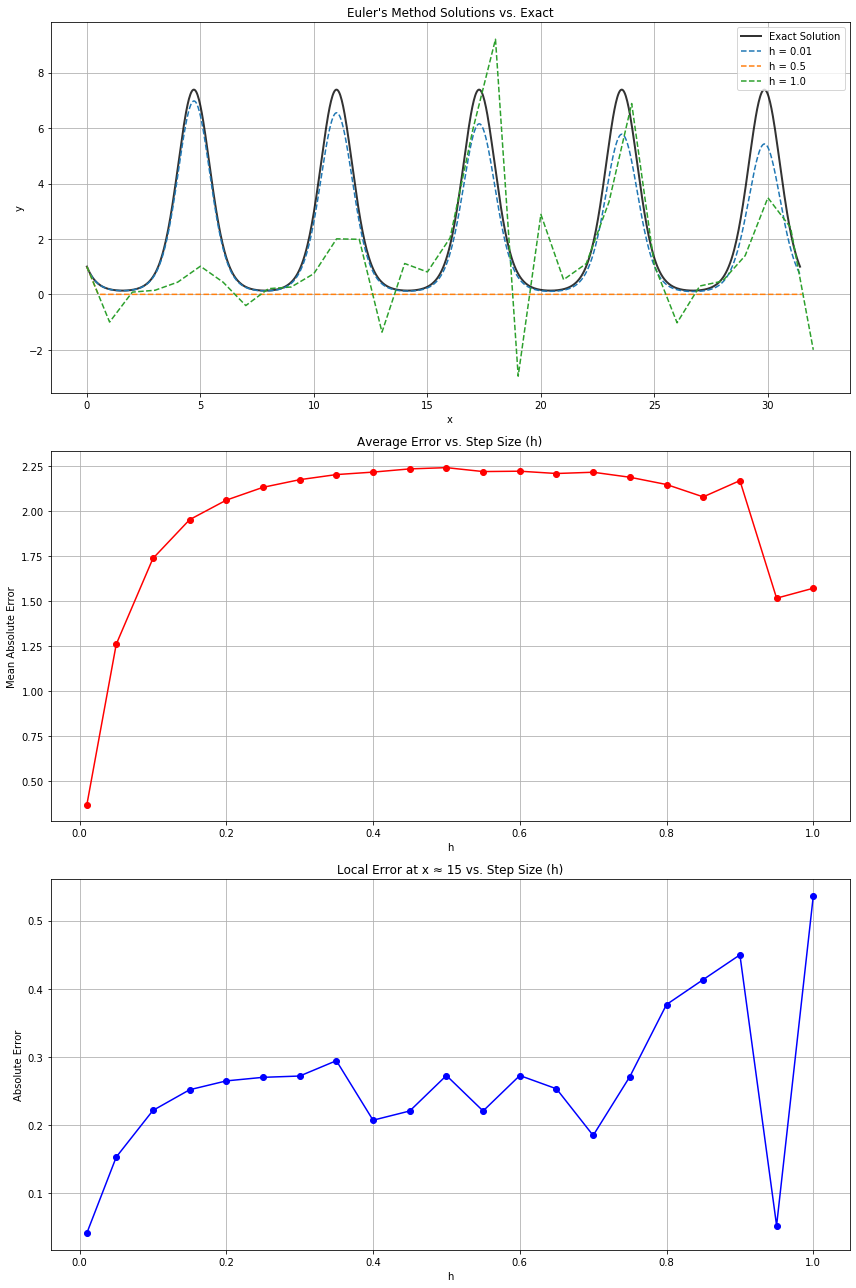

In [2]:
# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 18))

# Plotting Euler's Method for each h
x_fine = np.linspace(x_start, x_end, 1000)
ax1.plot(x_fine, exact_sol(x_fine), 'k', lw=2, label="Exact Solution", alpha=0.8)
for x, y, h in results_h:
    if h in [0.01, 0.15, 0.5, 1.0]:
        ax1.plot(x, y, '--', label=f'h = {h}')

ax1.set_title("Euler's Method Solutions vs. Exact")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend(loc='upper right')
ax1.grid(True)

# Plotting Average Error vs h
ax2.plot(h_values, avg_errors, 'ro-', label="Avg Error")
ax2.set_title("Average Error vs. Step Size (h)")
ax2.set_xlabel("h")
ax2.set_ylabel("Mean Absolute Error")
ax2.grid(True)

# Plot 3: Local Error at x ≈ 15 vs h
ax3.plot(h_values, local_errors_at_15, 'bo-', label="Local Error at x≈15")
ax3.set_title("Local Error at x ≈ 15 vs. Step Size (h)")
ax3.set_xlabel("h")
ax3.set_ylabel("Absolute Error")
ax3.grid(True)

plt.tight_layout()
plt.show()

## Write Up

What are we seeing, and why?

For a small step size like 0.01, the Euler equation almost perfectly  tracks the exact solution, $y(x) = e^{-2\sin(x)}$, due to the usage of "straight-line" guesses that stay close to the actual curve. However, as h increases, the algorithm becomes less precise and "misses" the turns of the periodic function and shoots straight ahead, creating this "jagged" plot. Since Euler is a first-order method, this global error is categorized as O(h), which means the error grows linearly with th step size. and doubling h will roughly double your average error.


Stability Analysis

The numerical stability of this system is governed by the condition $|1 + h\lambda| \le 1$. In this specific ODE, the time-varying $\lambda$ is $-2\cos(x)$, which reaches its most dangerous negative value at -2. This dictates a strict mathematical stability limit of $h \le 1$. If your step size exceeds this, the solution won't just be inaccurate—it will "blow up" toward infinity. This instability is highly visible through the "compounding effect" at $x \approx 15$, where small local errors from early steps are amplified by the repeated growth and decay cycles of the periodic function. Because the exact solution is bounded between $e^{-2}$ and $e^2$, any "zig-zag" behavior that escapes these bounds is a definitive sign that the step size is too large to resolve the physics of the system.